In [ ]:
!unzip /content/archive.zip

Archive:  /content/archive.zip
  inflating: customers.csv           
  inflating: discounts.csv           
  inflating: employees.csv           
  inflating: products.csv            
  inflating: stores.csv              
  inflating: transactions.csv        


In [ ]:
import pandas as pd
import os

# List of extracted CSV files from the unzip output
files = ['customers.csv', 'discounts.csv', 'employees.csv', 'products.csv', 'stores.csv', 'transactions.csv']

for file in files:
    if os.path.exists(file):
        print(f'\n--- Inspecting: {file} ---')
        df = pd.read_csv(file)
        # Using info() to show columns, non-null counts, and dtypes
        df.info()
    else:
        print(f'File {file} not found.')


--- Inspecting: customers.csv ---


/tmp/ipykernel_1976/783512494.py:10: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1643306 entries, 0 to 1643305
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Customer ID    1643306 non-null  int64 
 1   Name           1643306 non-null  object
 2   Email          1643306 non-null  object
 3   Telephone      1643306 non-null  object
 4   City           1643306 non-null  object
 5   Country        1643306 non-null  object
 6   Gender         1643306 non-null  object
 7   Date Of Birth  1643306 non-null  object
 8   Job Title      1059121 non-null  object
dtypes: int64(1), object(8)
memory usage: 112.8+ MB

--- Inspecting: discounts.csv ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Start         181 non-null    object 
 1   End           181 non-null    object 
 2   Discont       181 non-nul

## Version 1


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb

def build_feature_matrix():
    # 1. Load Data with strict dtypes
    print("Loading data...")
    transactions = pd.read_csv('transactions.csv', parse_dates=['Date'])
    products = pd.read_csv('products.csv')
    stores = pd.read_csv('stores.csv')
    discounts = pd.read_csv('discounts.csv', parse_dates=['Start', 'End'])

    # 2. Standardize Time Grain (Weekly to reduce sparsity)
    # Aligning to the start of the week (Monday)
    transactions['Week'] = transactions['Date'].dt.to_period('W').dt.start_time

    # 3. Base Aggregation (Store + Product + Week)
    print("Aggregating transactions...")
    weekly_sales = transactions.groupby(['Week', 'Store ID', 'Product ID']).agg(
        Total_Quantity=('Quantity', 'sum'),
        Avg_Unit_Price=('Unit Price', 'mean')
    ).reset_index()

    # 4. Handle Discounts (Explode date ranges into a daily lookup, then aggregate to weekly)
    print("Mapping active discounts...")
    # Create a row for every active day of a discount
    discounts['Date'] = discounts.apply(lambda row: pd.date_range(row['Start'], row['End']), axis=1)
    daily_discounts = discounts.explode('Date')[['Date', 'Category', 'Sub Category', 'Discont']]
    daily_discounts['Week'] = daily_discounts['Date'].dt.to_period('W').dt.start_time

    # Take the max discount applied in that week for a given category
    weekly_discounts = daily_discounts.groupby(['Week', 'Category', 'Sub Category'])['Discont'].max().reset_index()
    weekly_discounts.rename(columns={'Discont': 'Max_Discount'}, inplace=True)

    # 5. Merge Metadata
    print("Merging spatial and metadata...")
    df = weekly_sales.merge(products[['Product ID', 'Category', 'Sub Category', 'Production Cost']], on='Product ID', how='left')
    df = df.merge(stores[['Store ID', 'Country', 'Latitude', 'Longitude']], on='Store ID', how='left')

    # Merge the discount features based on Category and Week
    df = df.merge(weekly_discounts, on=['Week', 'Category', 'Sub Category'], how='left')
    df['Max_Discount'] = df['Max_Discount'].fillna(0) # 0 discount if no promo active

    # 6. Feature Engineering: Temporal & Lags
    print("Engineering lag features...")
    df = df.sort_values(['Store ID', 'Product ID', 'Week'])

    # Time features
    df['Month'] = df['Week'].dt.month
    df['Week_of_Year'] = df['Week'].dt.isocalendar().week.astype(int)

    # Lag features (What were the sales 1 week ago? 4 weeks ago?)
    df['Lag_1_Wk_Qty'] = df.groupby(['Store ID', 'Product ID'])['Total_Quantity'].shift(1)
    df['Lag_4_Wk_Qty'] = df.groupby(['Store ID', 'Product ID'])['Total_Quantity'].shift(4)

    # Rolling features (Momentum)
    df['Rolling_4W_Avg'] = df.groupby(['Store ID', 'Product ID'])['Total_Quantity'].transform(
        lambda x: x.shift(1).rolling(window=4, min_periods=1).mean()
    )

    # Drop rows with NaNs caused by lagging (burn-in period)
    df = df.dropna(subset=['Lag_1_Wk_Qty', 'Lag_4_Wk_Qty']).reset_index(drop=True)

    return df

df_features = build_feature_matrix()

Loading data...
Aggregating transactions...
Mapping active discounts...
Merging spatial and metadata...
Engineering lag features...


In [ ]:
def train_forecasting_model(df):
    # 1. Define Temporal Split (e.g., last 4 weeks as the holdout/test set)
    cutoff_date = df['Week'].max() - pd.Timedelta(weeks=4)

    train = df[df['Week'] <= cutoff_date].copy()
    test = df[df['Week'] > cutoff_date].copy()

    # 2. Define Features
    target = 'Total_Quantity'
    features = [
        'Month', 'Week_of_Year', 'Avg_Unit_Price', 'Max_Discount',
        'Production Cost', 'Latitude', 'Longitude',
        'Lag_1_Wk_Qty', 'Lag_4_Wk_Qty', 'Rolling_4W_Avg',
        'Store ID', 'Product ID', 'Category', 'Sub Category', 'Country'
    ]

    categorical_features = ['Store ID', 'Product ID', 'Category', 'Sub Category', 'Country']

    # Convert categoricals to 'category' dtype for LightGBM
    for col in categorical_features:
        train[col] = train[col].astype('category')
        test[col] = test[col].astype('category')

    # 3. Initialize LightGBM Dataset
    dtrain = lgb.Dataset(train[features], label=train[target])
    dvalid = lgb.Dataset(test[features], label=test[target], reference=dtrain)

    # 4. Model Hyperparameters (Poisson objective is critical here)
    params = {
        'objective': 'poisson',
        #'objective': 'tweedie',
        #'tweedie_variance_power': 1.15,
        # Best for zero-inflated count data
        'metric': 'rmse',             # Root Mean Squared Error
        'learning_rate': 0.05,
        'num_leaves': 63,             # Allows for complex interactions
        'min_data_in_leaf': 50,       # Prevents overfitting on sparse SKUs
        'feature_fraction': 0.8,      # Column subsampling
        'bagging_fraction': 0.8,      # Row subsampling
        'bagging_freq': 1,
        'verbose': -1
    }

    print("Training LightGBM Model...")
    # 5. Train Model with Early Stopping
    model = lgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    valid_sets=[dtrain, dvalid],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=1)   # Print every iteration
    ]
)

    # 6. Generate Predictions
    test['Forecast_Quantity'] = model.predict(test[features])

    return model, test

model, test_results = train_forecasting_model(df_features)

Training LightGBM Model...
[1]	train's rmse: 1.523	valid's rmse: 0.920308
Training until validation scores don't improve for 50 rounds
[2]	train's rmse: 1.50107	valid's rmse: 0.90727
[3]	train's rmse: 1.47946	valid's rmse: 0.895178
[4]	train's rmse: 1.46017	valid's rmse: 0.884283
[5]	train's rmse: 1.4461	valid's rmse: 0.874177
[6]	train's rmse: 1.42653	valid's rmse: 0.864432
[7]	train's rmse: 1.40939	valid's rmse: 0.855893
[8]	train's rmse: 1.39228	valid's rmse: 0.847762
[9]	train's rmse: 1.37612	valid's rmse: 0.840289
[10]	train's rmse: 1.36229	valid's rmse: 0.832608
[11]	train's rmse: 1.34824	valid's rmse: 0.826085
[12]	train's rmse: 1.33616	valid's rmse: 0.820264
[13]	train's rmse: 1.32516	valid's rmse: 0.815238
[14]	train's rmse: 1.31382	valid's rmse: 0.810156
[15]	train's rmse: 1.30461	valid's rmse: 0.80458
[16]	train's rmse: 1.29481	valid's rmse: 0.800293
[17]	train's rmse: 1.28627	valid's rmse: 0.796628
[18]	train's rmse: 1.27789	valid's rmse: 0.793123
[19]	train's rmse: 1.27183

In [ ]:
def calculate_wmape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)

wmape_score = calculate_wmape(test_results['Total_Quantity'], test_results['Forecast_Quantity'])
print(f"Global Model WMAPE: {wmape_score:.2%}")

# Look at Feature Importance to see what drives demand
importance = pd.DataFrame({
    'Feature': model.feature_name(),
    'Importance': model.feature_importance(importance_type='gain')
}).sort_values('Importance', ascending=False)

print("\nTop 5 Demand Drivers:")
print(importance.head(5))

Global Model WMAPE: 37.63%

Top 5 Demand Drivers:
         Feature    Importance
1   Week_of_Year  2.638913e+06
10      Store_ID  9.872305e+05
0          Month  6.520830e+05
11    Product_ID  4.664570e+05
13  Sub_Category  4.053113e+05


## Version 2


In [1]:
!unzip /content/archive.zip

Archive:  /content/archive.zip
  inflating: customers.csv           
  inflating: discounts.csv           
  inflating: employees.csv           
  inflating: products.csv            
  inflating: stores.csv              
  inflating: transactions.csv        


In [2]:
import gc
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import lightgbm as lgb

from sklearn.metrics import mean_absolute_error, mean_squared_error

# ============================================================
# 1. LOAD DATA
# ============================================================

# If transactions is already loaded, skip this line.
# Use low_memory=False because your source contains mixed types.
transactions = pd.read_csv(
    "transactions.csv",
    low_memory=False,
    usecols=[
        "Product ID", "Store ID", "Date", "Quantity",
        "Unit Price", "Discount", "Transaction Type"
    ]
)

# Optional but recommended: product metadata for category features
products = pd.read_csv(
    "products.csv",
    usecols=["Product ID", "Category", "Sub Category", "Production Cost"]
)

# ============================================================
# 2. CLEAN AND RENAME
# ============================================================

transactions = transactions.rename(columns={
    "Product ID": "Product_ID",
    "Store ID": "Store_ID",
    "Quantity": "units_sold",
    "Unit Price": "unit_price",
    "Transaction Type": "transaction_type"
})

products = products.rename(columns={
    "Product ID": "Product_ID",
    "Sub Category": "Sub_Category",
    "Production Cost": "production_cost"
})

transactions["Date"] = pd.to_datetime(
    transactions["Date"],
    errors="coerce"
)

transactions["units_sold"] = pd.to_numeric(
    transactions["units_sold"],
    errors="coerce"
)

transactions["unit_price"] = pd.to_numeric(
    transactions["unit_price"],
    errors="coerce"
)

transactions["Discount"] = pd.to_numeric(
    transactions["Discount"],
    errors="coerce"
).fillna(0)

# Remove invalid rows
transactions = transactions.dropna(
    subset=["Date", "Store_ID", "Product_ID", "units_sold"]
).copy()

# Important:
# If Quantity contains returns as negatives, do NOT blindly remove them.
# For a first demand model, use only actual sales.
if "transaction_type" in transactions.columns:
    print("Transaction types:")
    print(transactions["transaction_type"].value_counts().head(20))

# Keep positive sales demand only.
transactions = transactions[transactions["units_sold"] > 0].copy()

print("Clean transaction rows:", len(transactions))
print("Date range:", transactions["Date"].min(), "to", transactions["Date"].max())

# ============================================================
# 3. AGGREGATE TO DAILY STORE-PRODUCT DEMAND
# ============================================================

# Transaction-level rows should NOT be used directly for time-series lags.
# Aggregate all invoice lines into one daily demand value per Store + Product.
daily_sales = (
    transactions
    .groupby(["Date", "Store_ID", "Product_ID"], as_index=False)
    .agg(
        units_sold=("units_sold", "sum"),
        avg_unit_price=("unit_price", "mean"),
        avg_discount=("Discount", "mean"),
        transaction_count=("units_sold", "size")
    )
)

print("Daily aggregated rows:", len(daily_sales))

# Free memory after aggregation
del transactions
gc.collect()

# ============================================================
# 4. MERGE PRODUCT INFORMATION
# ============================================================

daily_sales = daily_sales.merge(
    products,
    on="Product_ID",
    how="left"
)

del products
gc.collect()

# ============================================================
# 5. DATE FEATURES
# ============================================================

daily_sales["year"] = daily_sales["Date"].dt.year
daily_sales["month"] = daily_sales["Date"].dt.month
daily_sales["quarter"] = daily_sales["Date"].dt.quarter
daily_sales["week_of_year"] = (
    daily_sales["Date"].dt.isocalendar().week.astype("int16")
)
daily_sales["day_of_week"] = daily_sales["Date"].dt.dayofweek
daily_sales["day_of_month"] = daily_sales["Date"].dt.day
daily_sales["is_weekend"] = (
    daily_sales["day_of_week"] >= 5
).astype("int8")

daily_sales["month_sin"] = np.sin(
    2 * np.pi * daily_sales["month"] / 12
)
daily_sales["month_cos"] = np.cos(
    2 * np.pi * daily_sales["month"] / 12
)
daily_sales["week_sin"] = np.sin(
    2 * np.pi * daily_sales["week_of_year"] / 52
)
daily_sales["week_cos"] = np.cos(
    2 * np.pi * daily_sales["week_of_year"] / 52
)

# ============================================================
# 6. CREATE STORE-PRODUCT LAGS
# ============================================================

daily_sales = daily_sales.sort_values(
    ["Store_ID", "Product_ID", "Date"]
).reset_index(drop=True)

series_keys = ["Store_ID", "Product_ID"]

# Grouping ensures a product's history never mixes with another
# product or store.
grouped_sales = daily_sales.groupby(
    series_keys,
    observed=True
)["units_sold"]

lag_periods = [1, 2, 3, 7, 14, 28]

for lag in lag_periods:
    daily_sales[f"lag_{lag}"] = grouped_sales.shift(lag)

# Rolling features must use shift(1), otherwise today's units_sold
# leaks into today's rolling statistic.
for window in [7, 14, 28]:
    shifted_sales = grouped_sales.shift(1)

    daily_sales[f"roll_mean_{window}"] = (
        shifted_sales
        .groupby(
            [daily_sales["Store_ID"], daily_sales["Product_ID"]],
            observed=True
        )
        .transform(
            lambda x: x.rolling(window, min_periods=3).mean()
        )
    )

    daily_sales[f"roll_std_{window}"] = (
        shifted_sales
        .groupby(
            [daily_sales["Store_ID"], daily_sales["Product_ID"]],
            observed=True
        )
        .transform(
            lambda x: x.rolling(window, min_periods=3).std()
        )
    )

    daily_sales[f"roll_max_{window}"] = (
        shifted_sales
        .groupby(
            [daily_sales["Store_ID"], daily_sales["Product_ID"]],
            observed=True
        )
        .transform(
            lambda x: x.rolling(window, min_periods=3).max()
        )
    )

daily_sales["pct_change_lag1"] = (
    (daily_sales["lag_1"] - daily_sales["lag_2"]) /
    (daily_sales["lag_2"].abs() + 1)
).clip(-5, 5)

# Need at least 28 historical observations because of lag_28.
feat = daily_sales.dropna(subset=["lag_28"]).copy()

# Fill rolling standard-deviation nulls.
rolling_std_cols = [
    "roll_std_7",
    "roll_std_14",
    "roll_std_28"
]

feat[rolling_std_cols] = feat[rolling_std_cols].fillna(0)

print("Feature dataset shape:", feat.shape)

# ============================================================
# 7. CATEGORICAL FEATURES
# ============================================================

categorical_cols = [
    "Store_ID",
    "Product_ID",
    "Category",
    "Sub_Category"
]

categorical_cols = [
    col for col in categorical_cols
    if col in feat.columns
]

for col in categorical_cols:
    feat[col] = feat[col].fillna("Unknown").astype("category")

# ============================================================
# 8. TIME-BASED TRAIN / VALIDATION / TEST SPLIT
# ============================================================

all_dates = np.sort(feat["Date"].unique())

train_end = all_dates[int(len(all_dates) * 0.70)]
valid_end = all_dates[int(len(all_dates) * 0.85)]

train = feat[feat["Date"] <= train_end].copy()

valid = feat[
    (feat["Date"] > train_end) &
    (feat["Date"] <= valid_end)
].copy()

test = feat[feat["Date"] > valid_end].copy()

print("\nTrain period:", train["Date"].min(), "to", train["Date"].max())
print("Validation period:", valid["Date"].min(), "to", valid["Date"].max())
print("Test period:", test["Date"].min(), "to", test["Date"].max())

print("\nTrain rows:", len(train))
print("Validation rows:", len(valid))
print("Test rows:", len(test))

# ============================================================
# 9. SELECT FEATURES
# ============================================================

target_col = "units_sold"

feature_cols = [
    "Store_ID",
    "Product_ID",
    "Category",
    "Sub_Category",
    "avg_unit_price",
    "avg_discount",
    "transaction_count",
    "production_cost",
    "year",
    "month",
    "quarter",
    "week_of_year",
    "day_of_week",
    "day_of_month",
    "is_weekend",
    "month_sin",
    "month_cos",
    "week_sin",
    "week_cos",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_28",
    "roll_mean_7",
    "roll_std_7",
    "roll_max_7",
    "roll_mean_14",
    "roll_std_14",
    "roll_max_14",
    "roll_mean_28",
    "roll_std_28",
    "roll_max_28",
    "pct_change_lag1"
]

feature_cols = [
    col for col in feature_cols
    if col in feat.columns
]

# Fill remaining numerical missing values.
numeric_features = [
    col for col in feature_cols
    if col not in categorical_cols
]

for col in numeric_features:
    train[col] = train[col].fillna(train[col].median())
    valid[col] = valid[col].fillna(train[col].median())
    test[col] = test[col].fillna(train[col].median())

X_train = train[feature_cols]
y_train = train[target_col]

X_valid = valid[feature_cols]
y_valid = valid[target_col]

X_test = test[feature_cols]
y_test = test[target_col]

# ============================================================
# 10. TRAIN LIGHTGBM
# ============================================================

model = lgb.LGBMRegressor(
    objective="regression_l1",
    n_estimators=5000,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

model.fit(
    X_train,
    y_train,
    categorical_feature=categorical_cols,
    eval_set=[(X_valid, y_valid)],
    eval_metric="rmse",
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=150,
            verbose=True
        ),
        lgb.log_evaluation(period=100)
    ]
)

# ============================================================
# 11. TEST METRICS
# ============================================================

preds = model.predict(
    X_test,
    num_iteration=model.best_iteration_
)

preds = np.clip(preds, 0, None)

def wmape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    denominator = np.abs(y_true).sum()

    if denominator == 0:
        return np.nan

    return np.abs(y_true - y_pred).sum() / denominator

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
final_wmape = wmape(y_test, preds)

print("\n" + "=" * 50)
print("FINAL HOLDOUT TEST RESULTS")
print("=" * 50)
print(f"Best iteration: {model.best_iteration_}")
print(f"MAE:   {mae:.4f}")
print(f"RMSE:  {rmse:.4f}")
print(f"WMAPE: {final_wmape:.2%}")

# ============================================================
# 12. NAIVE BASELINE: LAST OBSERVED DEMAND
# ============================================================

naive_preds = test["lag_1"].values

naive_mae = mean_absolute_error(y_test, naive_preds)
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_preds))
naive_wmape = wmape(y_test, naive_preds)

print("\nNAIVE BASELINE (predict lag_1)")
print(f"MAE:   {naive_mae:.4f}")
print(f"RMSE:  {naive_rmse:.4f}")
print(f"WMAPE: {naive_wmape:.2%}")

improvement = (
    (naive_wmape - final_wmape) / naive_wmape
) * 100

print(f"\nWMAPE improvement over naive baseline: {improvement:.2f}%")

# ============================================================
# 13. FEATURE IMPORTANCE
# ============================================================

importance_df = (
    pd.DataFrame({
        "Feature": feature_cols,
        "Importance": model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

print("\nTOP 20 DEMAND DRIVERS")
print(importance_df.head(20).to_string(index=False))

# ============================================================
# 14. SAVE PREDICTIONS AND ERROR ANALYSIS
# ============================================================

test_results = test[
    ["Date", "Store_ID", "Product_ID", "units_sold"]
].copy()

test_results["prediction"] = preds
test_results["absolute_error"] = np.abs(
    test_results["units_sold"] - test_results["prediction"]
)

store_error = (
    test_results
    .groupby("Store_ID", observed=True)
    .agg(
        actual_units=("units_sold", "sum"),
        predicted_units=("prediction", "sum"),
        absolute_error=("absolute_error", "sum")
    )
    .reset_index()
)

store_error["WMAPE"] = (
    store_error["absolute_error"] /
    store_error["actual_units"].replace(0, np.nan)
)

product_error = (
    test_results
    .groupby("Product_ID", observed=True)
    .agg(
        actual_units=("units_sold", "sum"),
        predicted_units=("prediction", "sum"),
        absolute_error=("absolute_error", "sum")
    )
    .reset_index()
)

product_error["WMAPE"] = (
    product_error["absolute_error"] /
    product_error["actual_units"].replace(0, np.nan)
)

print("\nWorst 10 stores by WMAPE:")
print(
    store_error
    .sort_values("WMAPE", ascending=False)
    .head(10)
    .to_string(index=False)
)

print("\nWorst 10 products by WMAPE:")
print(
    product_error
    .sort_values("WMAPE", ascending=False)
    .head(10)
    .to_string(index=False)
)

Transaction types:
transaction_type
Sale      6077200
Return     339627
Name: count, dtype: int64
Clean transaction rows: 6416827
Date range: 2023-01-01 00:00:00 to 2025-03-18 20:59:00
Daily aggregated rows: 6408706
Feature dataset shape: (661188, 37)

Train period: 2023-02-09 20:37:00 to 2024-12-06 11:44:00
Validation period: 2024-12-06 11:45:00 to 2025-01-15 18:47:00
Test period: 2025-01-15 18:48:00 to 2025-03-18 00:00:00

Train rows: 353245
Validation rows: 209968
Test rows: 97975
Training until validation scores don't improve for 150 rounds
[100]	valid_0's rmse: 0.406189	valid_0's l1: 0.0989905
[200]	valid_0's rmse: 0.406013	valid_0's l1: 0.0987624
[300]	valid_0's rmse: 0.40598	valid_0's l1: 0.0987548
Early stopping, best iteration is:
[236]	valid_0's rmse: 0.406005	valid_0's l1: 0.0987506

FINAL HOLDOUT TEST RESULTS
Best iteration: 236
MAE:   0.0994
RMSE:  0.4081
WMAPE: 9.03%

NAIVE BASELINE (predict lag_1)
MAE:   0.1820
RMSE:  0.5507
WMAPE: 16.53%

WMAPE improvement over naive ba

In [ ]:
importance_df.to_csv("feature_importance.csv", index=False)
test_results.to_csv("test_predictions.csv", index=False)
store_error.to_csv("store_error_analysis.csv", index=False)
product_error.to_csv("product_error_analysis.csv", index=False)

### 15. Save Model for Inference
We save the booster object to a text file. This contains the model structure and weights.

In [4]:
import os
model_filename = 'lgbm_demand_model.txt'
model.booster_.save_model(model_filename)

if os.path.exists(model_filename):
    print(f'Model successfully saved to: {model_filename}')
else:
    print('Failed to save the model.')

Model successfully saved to: lgbm_demand_model.txt


### 16. Run Inference using the Saved Model
We load the model using `lgb.Booster` and perform a prediction on the test features.

In [5]:
loaded_model = lgb.Booster(model_file='lgbm_demand_model.txt')

# Run inference
inference_preds = loaded_model.predict(X_test)

# Add to a new dataframe for comparison
inference_df = X_test.copy()
inference_df['predicted_units'] = np.clip(inference_preds, 0, None)

print("Inference completed.")
display(inference_df[['Store_ID', 'Product_ID', 'predicted_units']].head())

Inference completed.


,Store_ID,Product_ID,predicted_units
313477,1,11961,1.0
313478,1,11961,1.0
313479,1,11961,1.0
313480,1,11961,1.0
313481,1,11961,1.0


### 17. 7-Day Zoomed Forecast with Confidence Bands
We will take the first 7 days of the test set, calculate a confidence interval based on RMSE, and visualize the results day-by-day.

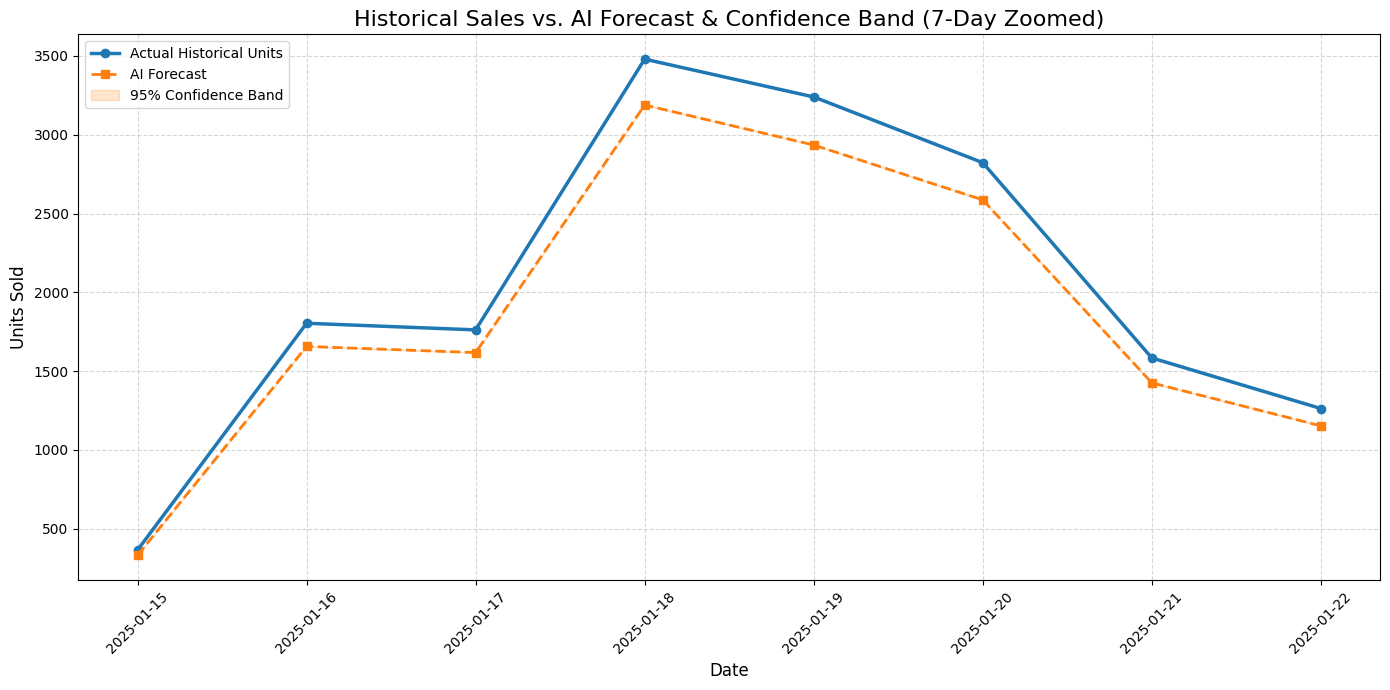

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare 7-day window
test_start = test['Date'].min()
forecast_end = test_start + pd.Timedelta(days=7)

# Get the actuals and predictions from our results for this window
forecast_df = test_results[(test_results['Date'] >= test_start) & (test_results['Date'] < forecast_end)].copy()

# 2. Estimate Confidence Band
# We use the RMSE calculated earlier as a proxy for the standard error of the prediction
std_error = 0.4081  # Based on the test RMSE calculated in cell 1Jm20uHSsRBO

# Aggregate daywise
daily_forecast = forecast_df.groupby(forecast_df['Date'].dt.date).agg({
    'units_sold': 'sum',
    'prediction': 'sum'
}).reset_index()
daily_forecast['Date'] = pd.to_datetime(daily_forecast['Date'])

# Simple confidence bound: +/- 1.96 * std_error (approx 95% interval for the mean prediction)
# Note: In a real scenario, this would scale with the volume of transactions aggregated
daily_forecast['lower_bound'] = np.clip(daily_forecast['prediction'] - (1.96 * std_error), 0, None)
daily_forecast['upper_bound'] = daily_forecast['prediction'] + (1.96 * std_error)

# 3. Visualization
plt.figure(figsize=(14, 7))

# Plot Actuals
plt.plot(daily_forecast['Date'], daily_forecast['units_sold'],
         label='Actual Historical Units', color='#1f77b4', marker='o', linewidth=2.5)

# Plot AI Forecast
plt.plot(daily_forecast['Date'], daily_forecast['prediction'],
         label='AI Forecast', color='#ff7f0e', linestyle='--', marker='s', linewidth=2)

# Confidence Band
plt.fill_between(daily_forecast['Date'],
                 daily_forecast['lower_bound'],
                 daily_forecast['upper_bound'],
                 color='#ff7f0e', alpha=0.2, label='95% Confidence Band')

plt.title('Historical Sales vs. AI Forecast & Confidence Band (7-Day Zoomed)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Units Sold', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.xticks(daily_forecast['Date'], rotation=45)
plt.tight_layout()
plt.show()

### 18. 7-Day Forecast Metrics Analysis
Calculation of WMAPE and RMSE specifically for the period visualized above (first 7 days of the test set).

In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Reuse the daily_forecast dataframe created in the previous step
# It contains aggregated daily units_sold (actual) and prediction

y_true_7d = daily_forecast['units_sold']
y_pred_7d = daily_forecast['prediction']

# 2. Calculate Metrics
rmse_7d = np.sqrt(mean_squared_error(y_true_7d, y_pred_7d))
wmape_7d = np.sum(np.abs(y_true_7d - y_pred_7d)) / np.sum(y_true_7d)

# 3. Display results
print(f"--- Metrics for the 7-Day Forecast Window ---")
print(f"RMSE:  {rmse_7d:.4f}")
print(f"WMAPE: {wmape_7d:.2%}")

# Comparison with overall test metrics
print(f"\n(For reference, Overall Test WMAPE was: {final_wmape:.2%})")

--- Metrics for the 7-Day Forecast Window ---
RMSE:  198.0599
WMAPE: 8.72%

(For reference, Overall Test WMAPE was: 9.03%)
